In [13]:
import helper_functions as hf
import plotters as pl
import importlib
import numpy as np

n_subj = 20  			# Number of subjects in each group
n_runs = 750	            # Number of simulation runs for FWER estimation
n_perm = 50	        # Number of permutations for permutation test
img_side_length = 64    # Side length of the square brain image in voxels
smoothing_sigma = 1.5 	# Standard deviation for Gaussian smoothing
alpha = 0.05      		# Significance level for FWER    
null_boundary = 1e-3    # Boundary value for null hypothesis in visualization

In [11]:
test_snrs =     [0, 0.1, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0]
test_sigmas =   [0, 0.1, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0]

# 2. Run Sweep
# n_runs=20 and n_perm=50 is LOW quality but fast
# High quality: n_runs=50, n_perm=100
sens_mat, fwer_mat = hf.run_2d_sweep_bonferroni(
    n_runs=n_runs,          
    n_subj=20,
    img_side=img_side_length,
    snr_levels=test_snrs,
    sigma_levels=test_sigmas,
    alpha=0.05,
    signal_radius=6,
    n_perm=n_perm,   
	null_boundary = null_boundary,
    noise = "normal"  
)


Starting 2D Sweep (Bonferroni): 14 Sigmas x 14 SNRs
  > Processing Sigma = 0...


KeyboardInterrupt: 

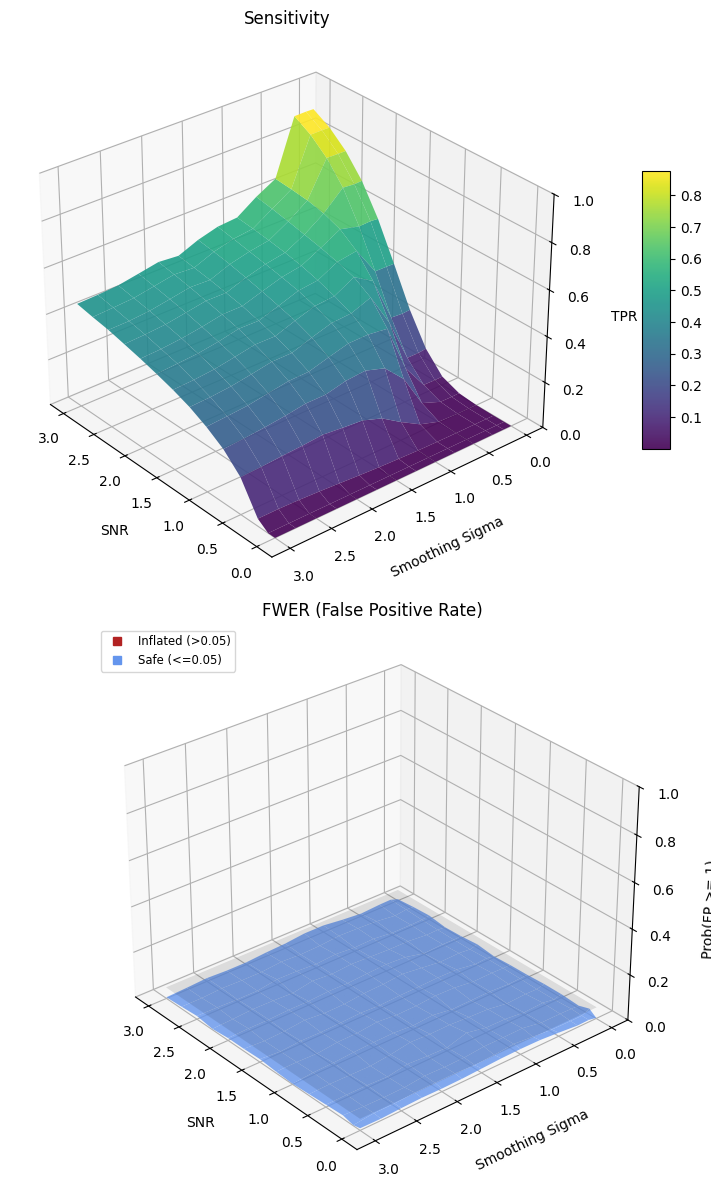

In [3]:
importlib.reload(pl)


pl.plot_3d_surfaces(test_snrs, test_sigmas, sens_mat, fwer_mat, elev=30, azim=140)

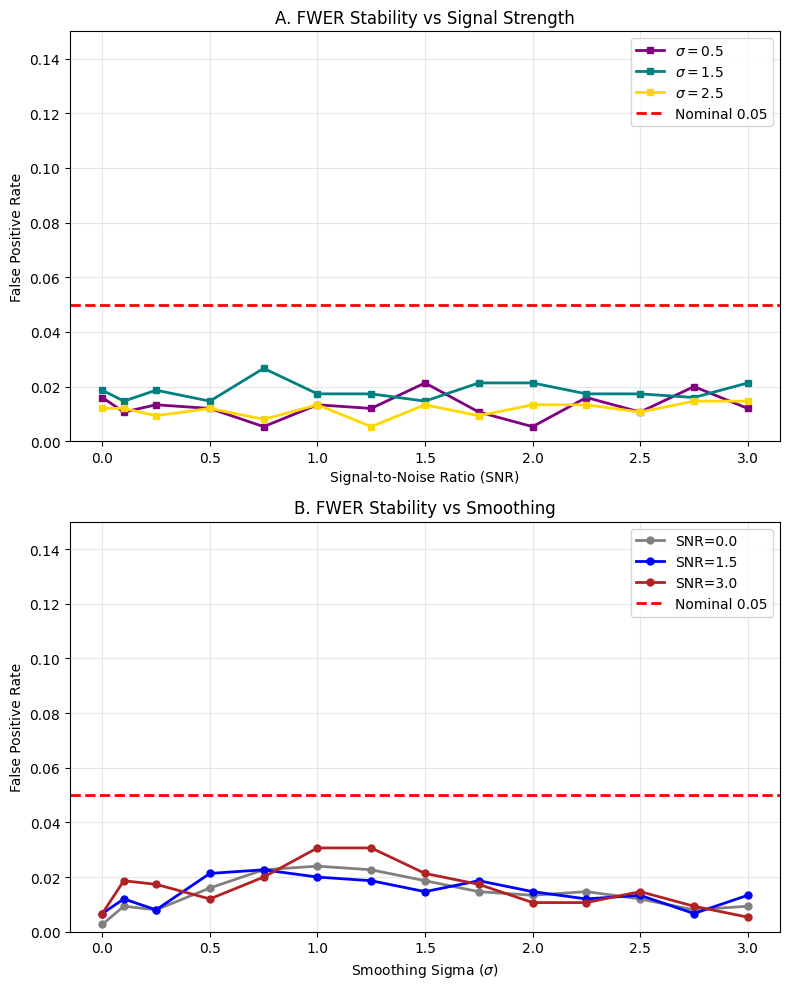

In [4]:
pl.plot_fwer_stability(test_snrs, test_sigmas, fwer_mat, np.array(test_sigmas), np.array(test_snrs))

In [14]:
importlib.reload(pl)

varied_n_metrics = []
n_values = [2,5,7,10,15,20,30,45,60]

for n_subj_temp in n_values:
    sens_mat, fwer_mat = hf.run_2d_sweep_bonferroni(
        n_runs=n_runs,          
        n_subj=n_subj_temp,
        img_side=img_side_length,
        snr_levels=test_snrs,
        sigma_levels=test_sigmas,
        alpha=0.05,
        signal_radius=6,
        n_perm=n_perm,   
        null_boundary = null_boundary,
        noise = "normal"       
    )
    varied_n_metrics.append((sens_mat,fwer_mat))
    

Starting 2D Sweep (Bonferroni): 14 Sigmas x 14 SNRs
  > Processing Sigma = 0...
  > Processing Sigma = 0.1...
  > Processing Sigma = 0.25...
  > Processing Sigma = 0.5...
  > Processing Sigma = 0.75...
  > Processing Sigma = 1.0...
  > Processing Sigma = 1.25...
  > Processing Sigma = 1.5...
  > Processing Sigma = 1.75...
  > Processing Sigma = 2.0...
  > Processing Sigma = 2.25...
  > Processing Sigma = 2.5...
  > Processing Sigma = 2.75...
  > Processing Sigma = 3.0...
Bonferroni Sweep Complete.
Starting 2D Sweep (Bonferroni): 14 Sigmas x 14 SNRs
  > Processing Sigma = 0...
  > Processing Sigma = 0.1...
  > Processing Sigma = 0.25...
  > Processing Sigma = 0.5...
  > Processing Sigma = 0.75...
  > Processing Sigma = 1.0...
  > Processing Sigma = 1.25...
  > Processing Sigma = 1.5...
  > Processing Sigma = 1.75...
  > Processing Sigma = 2.0...
  > Processing Sigma = 2.25...
  > Processing Sigma = 2.5...
  > Processing Sigma = 2.75...
  > Processing Sigma = 3.0...
Bonferroni Sweep Comp

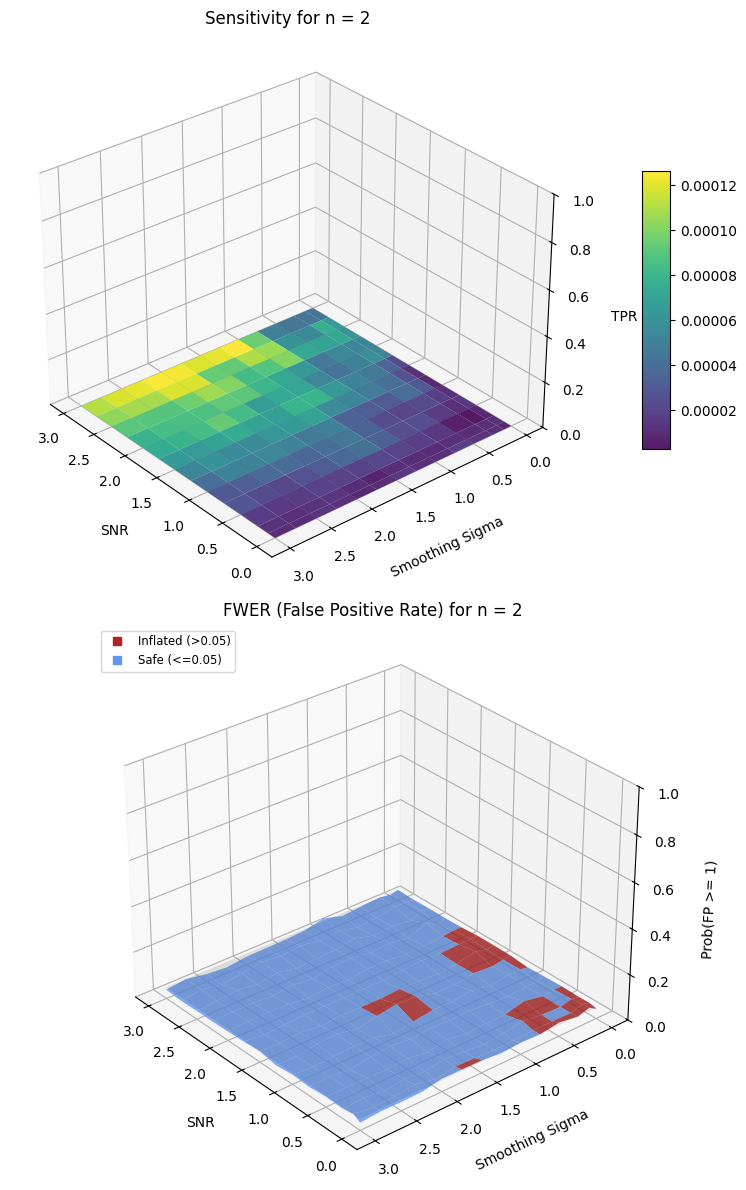

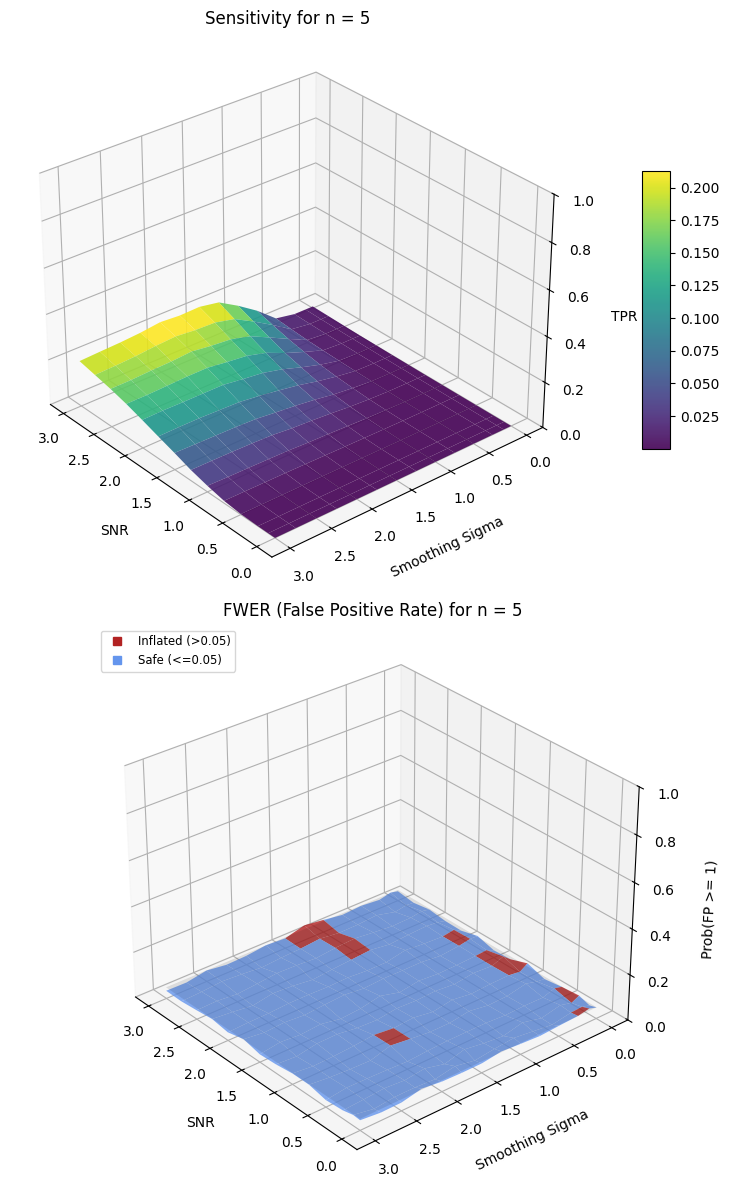

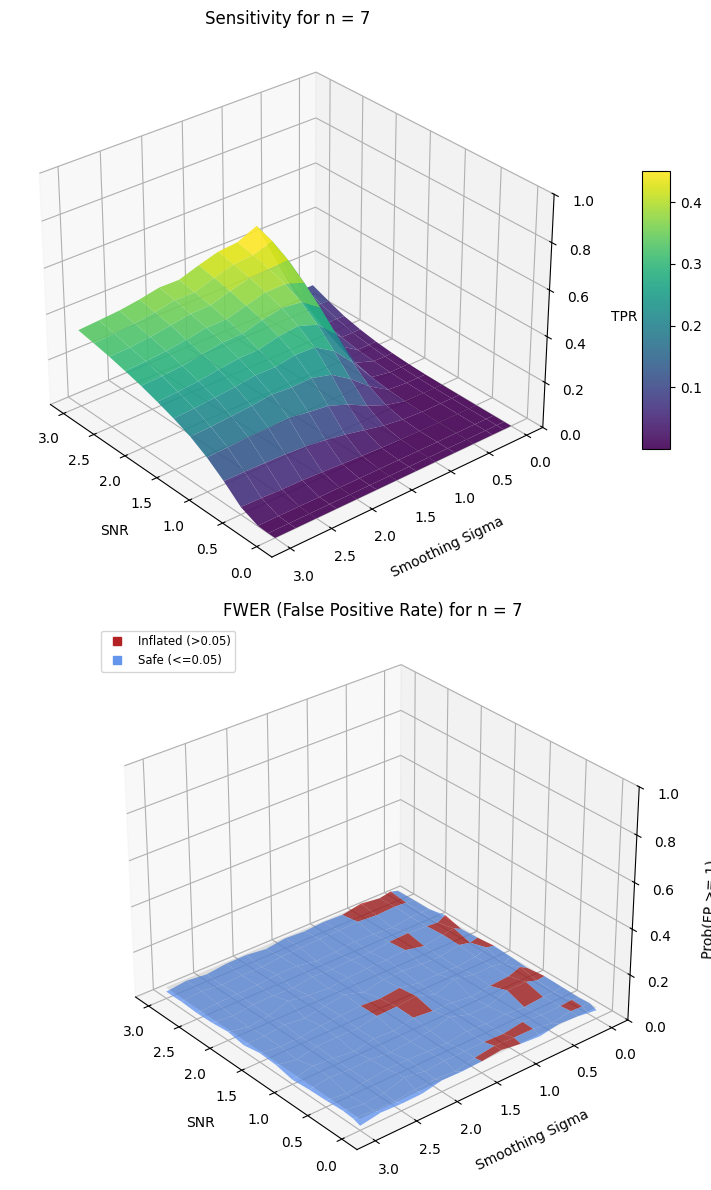

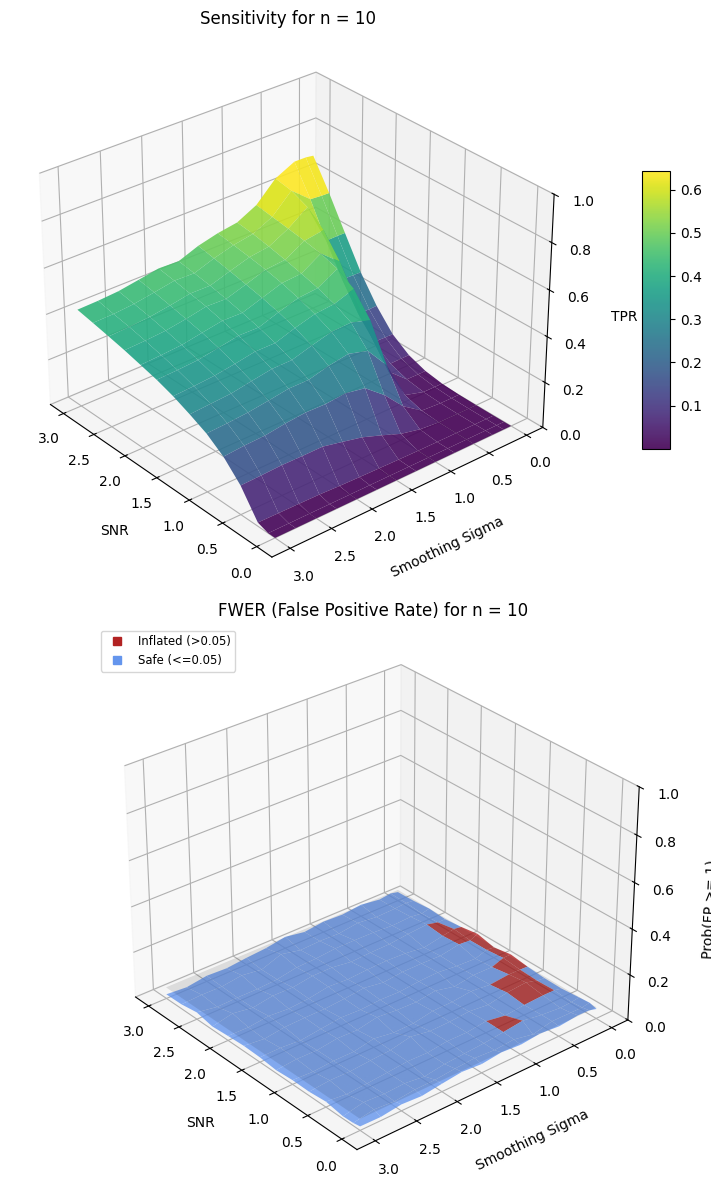

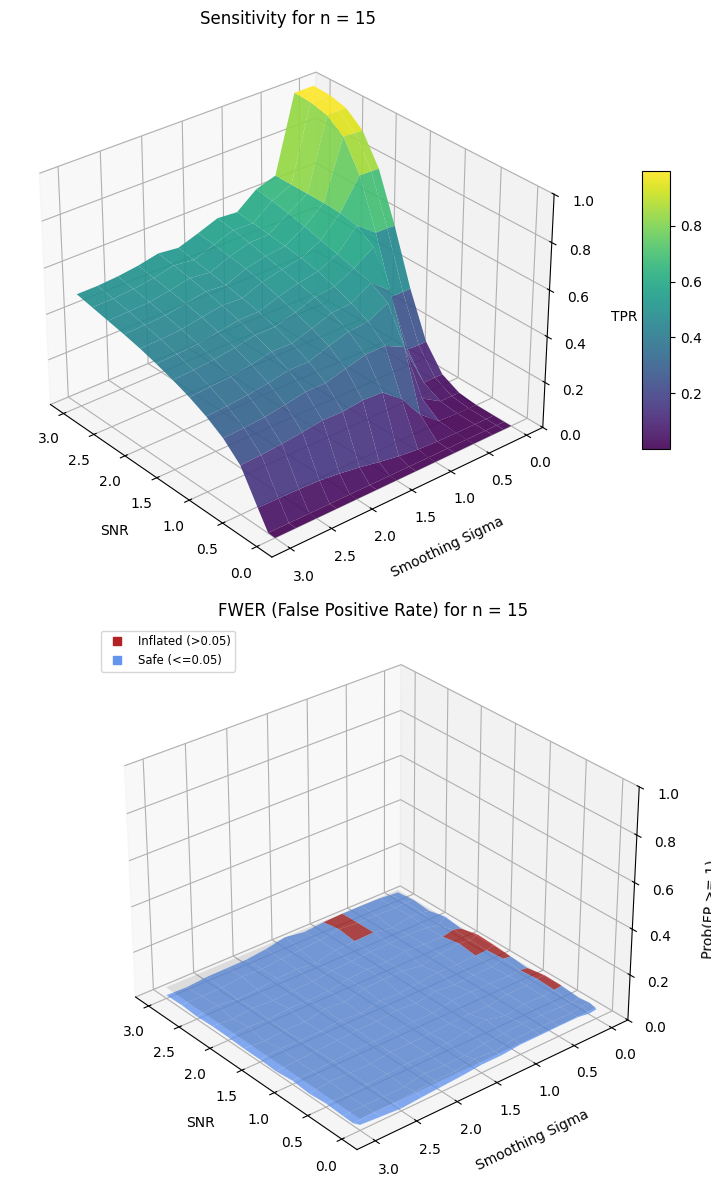

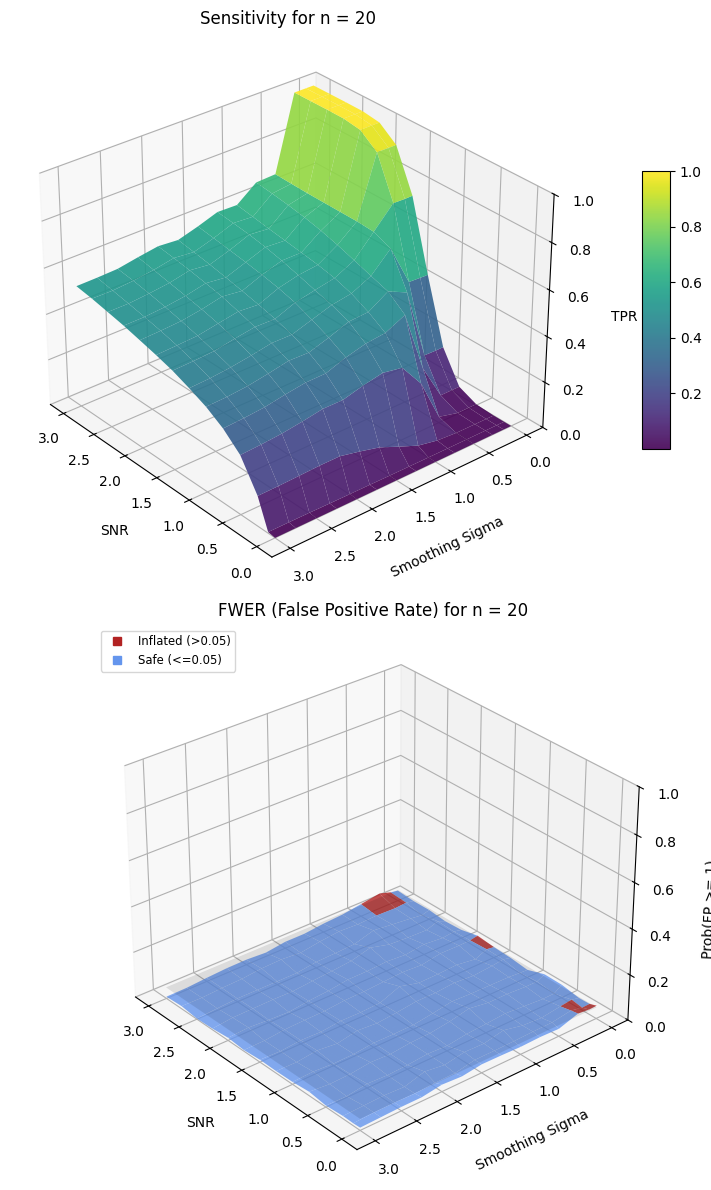

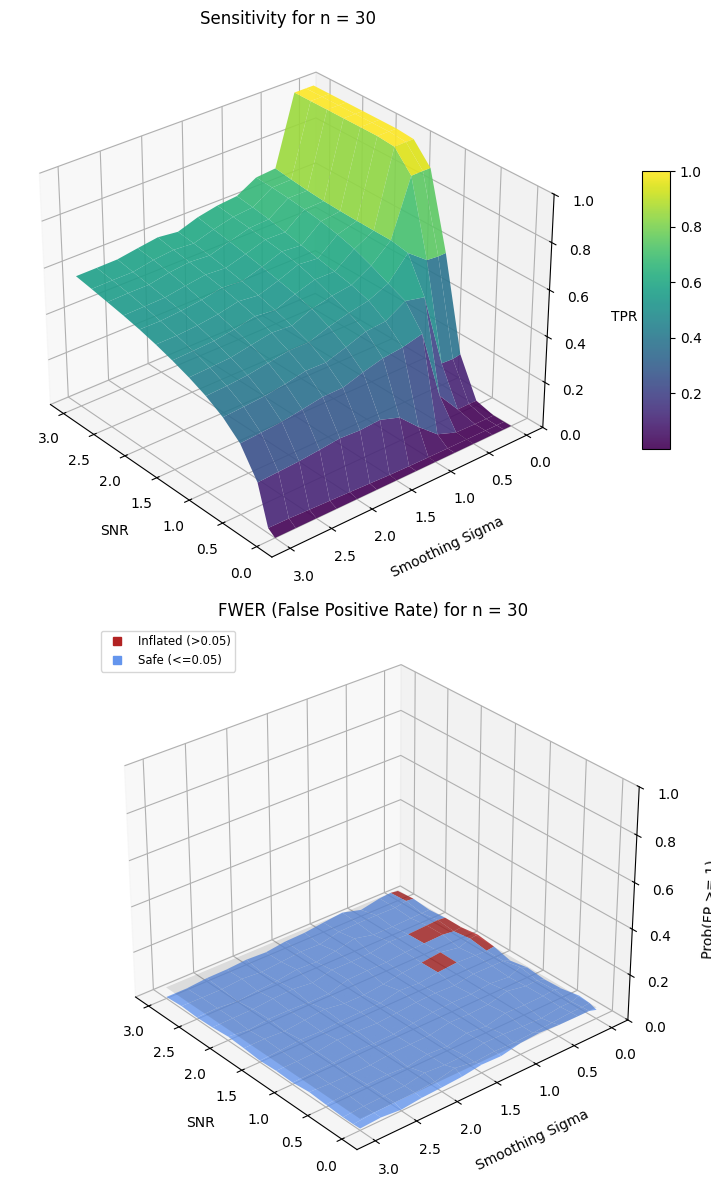

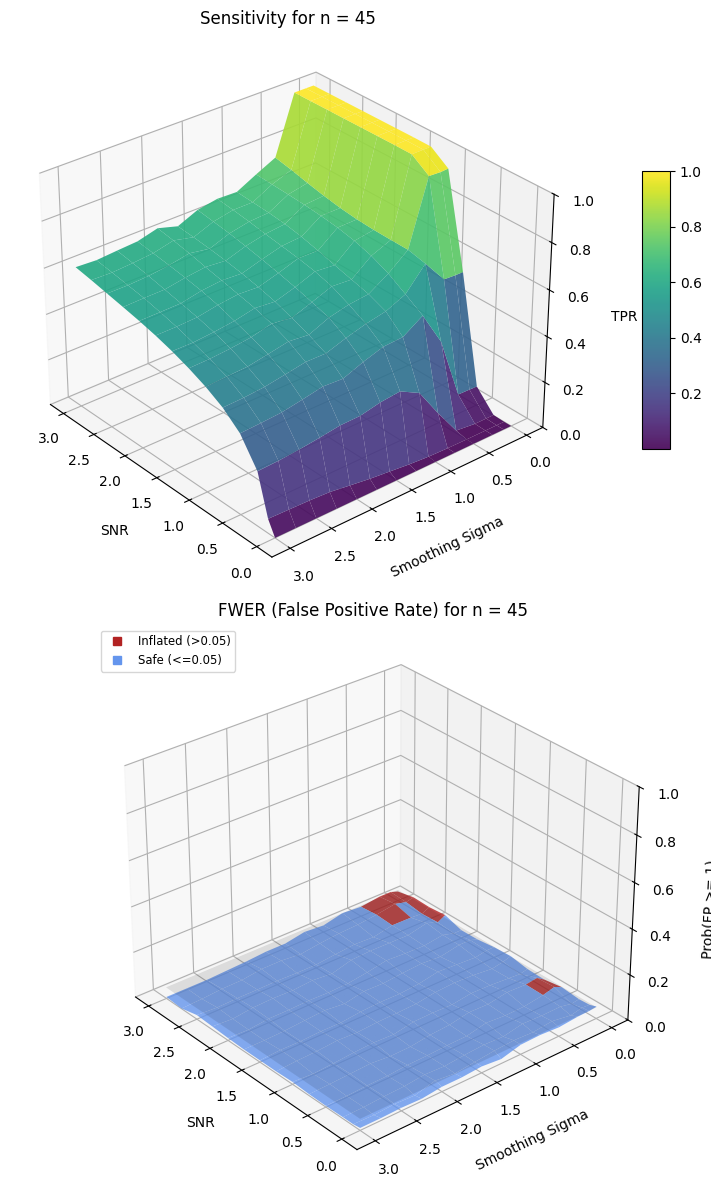

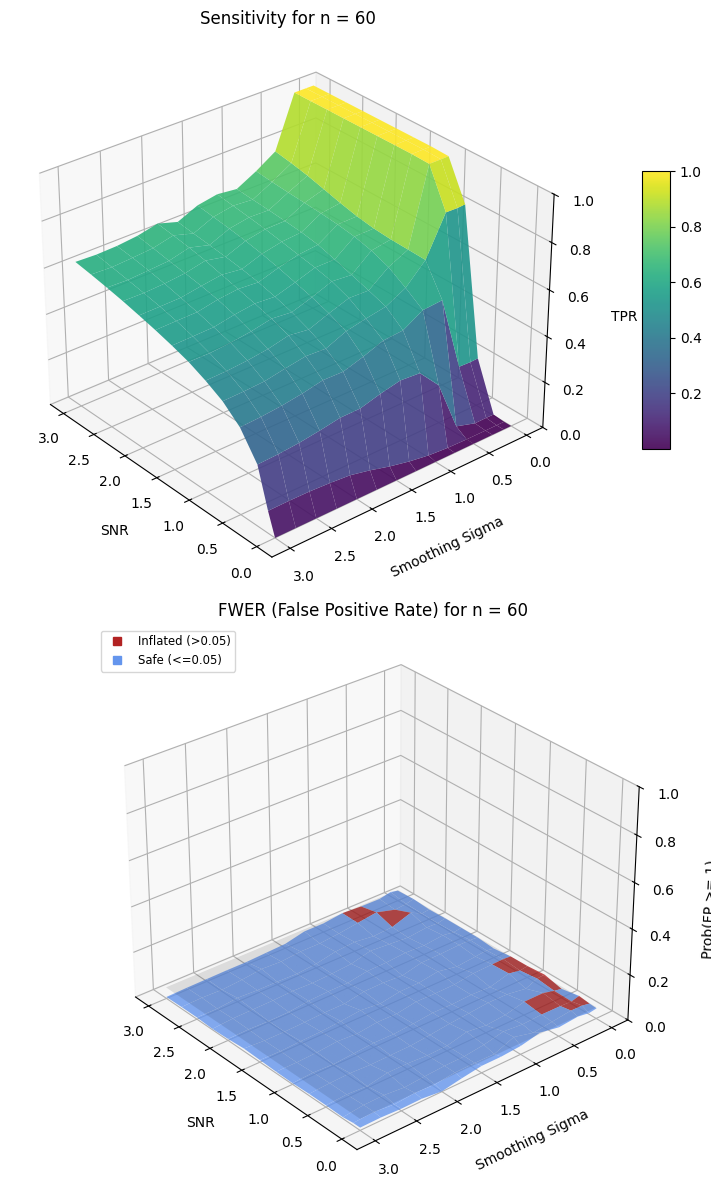

In [15]:
for n_subj_temp, (sens_mat_temp, fwer_mat_temp) in zip(n_values,varied_n_metrics):
    pl.plot_3d_surfaces(test_snrs, test_sigmas, sens_mat_temp, fwer_mat_temp, elev=30, azim=140, extra_title= " for n = " + str(n_subj_temp))
    

In [17]:
import pandas as pd

rows = []

for n_subj_temp, (sens_mat, fwer_mat) in zip(n_values, varied_n_metrics):

    for i, sigma in enumerate(test_sigmas):     # FIRST sigma
        for j, snr in enumerate(test_snrs):     # THEN snr

            rows.append({
                "fwer": fwer_mat[i, j],
                "sensitivity": sens_mat[i, j],
                "sm_sigma": sigma,
                "snr": snr,
                "n": n_subj_temp
            })

final_metrics_df = pd.DataFrame(rows)
final_metrics_df["method"] = "Bonferroni"
final_metrics_df["distribution"] = "normal"

In [19]:
# COLUMNS
# fwer:         metric variable
# sensitivity:  metric variable
# sm_sigma:     [0, 0.1, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0]
# snr:          [0, 0.1, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0]
# n:            [2,5,7,10,15,20,30,45,60]
# method:       ["voxelwise_perm"] , will add more later.
# rows of the dataframe are generated by taking all unique combinations of the values from the lists above.

final_metrics_df.to_csv("bonferroni_n.csv", index=False)